# Goal:
- Load processed multimodal sensor features
- Keep 3-class labels: rest / moderate / intense
- Run strict leave-one-file-out evaluation
- Compare QSVM vs Random Forest vs classical SVM
- Use per-file sampling to keep QSVM runtime manageable
- Save metrics and charts for reporting

## 1) Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

## 2) Qiskit imports

In [2]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

## 3) Paths

In [3]:
DATA_PATH = Path("../data/processed/activity_fusion_features_sensors_strict.csv")
OUTPUT_DIR = Path("../data/processed")
PLOTS_DIR = Path("../outputs/plots")
LOGS_DIR = Path("../outputs/logs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading from:", DATA_PATH.resolve())

Loading from: C:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ml_pipeline\data\processed\activity_fusion_features_sensors_strict.csv


## 4) Load dataset

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (366, 45)
['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'emg_raw_mean', 'emg_raw_std', 'emg_env_mean', 'emg_env_std', 'emg_rms', 'emg_mav', 'emg_wl', 'emg_zero_cross', 'emg_state_mean', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'az_mean', 'az_std', 'az_min', 'az_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_mag_energy', 'jerk_mean', 'jerk_std', 'label_name', 'label', 'source_file', 'window_start', 'window_end', 'n_samples']


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
2,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9
3,122.300000,5.375872,114.0,129.0,15.0,25.968000,0.189021,25.69,26.25,-0.056000,...,18848.170897,4.017341e+08,13013.301236,13811.219595,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:47.519406,2026-04-14 19:53:57.519406,10
4,126.900000,0.994429,126.0,129.0,3.0,25.461000,0.139400,25.25,25.69,-0.044000,...,21599.531893,4.433055e+08,11563.092523,13163.102565,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:57.519406,2026-04-14 19:54:07.519406,10


## 5) Check class distribution

In [5]:
print(df["label_name"].value_counts())
print(df["label"].value_counts())
print("Unique files:", df["source_file"].nunique())

label_name
moderate    148
intense     123
rest         95
Name: count, dtype: int64
label
1    148
2    123
0     95
Name: count, dtype: int64
Unique files: 15


## 6) Select a small feature subset

In [6]:
selected_features = [
    "hr_mean",
    "temp_mean",
    "emg_rms",
    "acc_mag_mean"
]

missing = [c for c in selected_features if c not in df.columns]
print("Missing features:", missing)

Missing features: []


## 7) Sample per file to keep QSVM manageable

In [7]:
MAX_WINDOWS_PER_FILE = 6

sampled_parts = []

for file_name in df["source_file"].unique():
    part = df[df["source_file"] == file_name].copy()
    part = part.sample(n=min(len(part), MAX_WINDOWS_PER_FILE), random_state=42)
    sampled_parts.append(part)

df_qsvm = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Reduced multiclass QSVM dataset shape:", df_qsvm.shape)
print("\nWindows per file:")
print(df_qsvm["source_file"].value_counts().sort_index())
print("\nLabel distribution:")
print(df_qsvm["label_name"].value_counts())

Reduced multiclass QSVM dataset shape: (90, 45)

Windows per file:
source_file
intense/intense_running_20260414_195242.csv      6
intense/intense_running_20260417_160438.csv      6
intense/intense_running_20260417_162157.csv      6
intense/intense_squats_20260411_223205.csv       6
intense/intense_squats_20260417_153856.csv       6
intense/intense_squats_20260417_154922.csv       6
moderate/moderate_stairs_20260411_224148.csv     6
moderate/moderate_stairs_20260417_163918.csv     6
moderate/moderate_stairs_20260417_164326.csv     6
moderate/moderate_walking_20260407_120447.csv    6
moderate/moderate_walking_20260417_150822.csv    6
moderate/moderate_walking_20260417_151525.csv    6
rest/rest_20260417_152340.csv                    6
rest/rest_20260417_152938.csv                    6
rest/rest_stressed_20260406_170652.csv           6
Name: count, dtype: int64

Label distribution:
label_name
moderate    36
intense     36
rest        18
Name: count, dtype: int64


## 8) Prepare X, y, groups

In [8]:
X_all = df_qsvm[selected_features].copy()
y_all = df_qsvm["label"].copy()
groups = df_qsvm["source_file"].copy()

print("X shape:", X_all.shape)
print("y distribution:\n", y_all.value_counts())
print("Number of files:", groups.nunique())

X shape: (90, 4)
y distribution:
 label
1    36
2    36
0    18
Name: count, dtype: int64
Number of files: 15


## 9) Build feature map

In [9]:
num_features = len(selected_features)

feature_map = zz_feature_map(
    feature_dimension=num_features,
    reps=1,
    entanglement="linear"
)

print(feature_map)

   ┌───┐┌───────────┐                                               »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■───────»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐     »
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■──»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├»
   ├───┤├───────────┤                                          └───┘»
3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────────────────»
   └───┘└───────────┘                                               »
«                                                                             »
«0: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«1: ──────────────────────────────────■───────────────────────────────────────»
«   ┌──────────────────────────────┐┌─┴─┐         

## 10) Save feature map figure

In [10]:
try:
    fig = feature_map.draw("mpl")
    fig.savefig(PLOTS_DIR / "qsvm_multiclass_feature_map.png", dpi=300, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Feature map figure could not be saved:", e)

## 11) Leave-one-file-out setup

In [11]:
unique_files = groups.unique()

print("Held-out files:", len(unique_files))
print(unique_files)

Held-out files: 15
<StringArray>
[ 'moderate/moderate_stairs_20260411_224148.csv',
    'intense/intense_squats_20260411_223205.csv',
 'moderate/moderate_walking_20260407_120447.csv',
 'moderate/moderate_walking_20260417_151525.csv',
   'intense/intense_running_20260414_195242.csv',
    'intense/intense_squats_20260417_153856.csv',
 'moderate/moderate_walking_20260417_150822.csv',
   'intense/intense_running_20260417_160438.csv',
  'moderate/moderate_stairs_20260417_163918.csv',
                 'rest/rest_20260417_152938.csv',
    'intense/intense_squats_20260417_154922.csv',
        'rest/rest_stressed_20260406_170652.csv',
   'intense/intense_running_20260417_162157.csv',
  'moderate/moderate_stairs_20260417_164326.csv',
                 'rest/rest_20260417_152340.csv']
Length: 15, dtype: str


## 12) Strict multiclass QSVM evaluation

In [12]:
all_true_qsvm = []
all_preds_qsvm = []
results_qsvm = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train = X_all[train_idx].copy()
    X_test = X_all[test_idx].copy()
    y_train = y_all[train_idx].copy()
    y_test = y_all[test_idx].copy()

    # Classical scaling
    std_scaler = StandardScaler()
    X_train_std = std_scaler.fit_transform(X_train)
    X_test_std = std_scaler.transform(X_test)

    # Quantum-friendly scaling
    minmax_scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_train_q = minmax_scaler.fit_transform(X_train_std)
    X_test_q = minmax_scaler.transform(X_test_std)

    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    qsvm = QSVC(quantum_kernel=quantum_kernel)

    qsvm.fit(X_train_q, y_train)
    y_pred_qsvm = qsvm.predict(X_test_q)

    acc = accuracy_score(y_test, y_pred_qsvm)

    results_qsvm.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true_qsvm.extend(y_test.tolist())
    all_preds_qsvm.extend(y_pred_qsvm.tolist())

results_qsvm_df = pd.DataFrame(results_qsvm)
results_qsvm_df

,test_file,n_test_windows,accuracy
0,moderate/moderate_stairs_20260411_224148.csv,6,0.166667
1,intense/intense_squats_20260411_223205.csv,6,0.166667
2,moderate/moderate_walking_20260407_120447.csv,6,0.000000
3,moderate/moderate_walking_20260417_151525.csv,6,1.000000
4,intense/intense_running_20260414_195242.csv,6,0.333333
5,intense/intense_squats_20260417_153856.csv,6,1.000000
6,moderate/moderate_walking_20260417_150822.csv,6,0.500000
7,intense/intense_running_20260417_160438.csv,6,1.000000
8,moderate/moderate_stairs_20260417_163918.csv,6,0.333333
9,rest/rest_20260417_152938.csv,6,1.000000


## 13) Strict multiclass RF evaluation

In [13]:
all_true_rf = []
all_preds_rf = []
results_rf = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train = X_all[train_idx].copy()
    X_test = X_all[test_idx].copy()
    y_train = y_all[train_idx].copy()
    y_test = y_all[test_idx].copy()

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=8,
        min_samples_leaf=4,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rf)

    results_rf.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true_rf.extend(y_test.tolist())
    all_preds_rf.extend(y_pred_rf.tolist())

results_rf_df = pd.DataFrame(results_rf)
results_rf_df

,test_file,n_test_windows,accuracy
0,moderate/moderate_stairs_20260411_224148.csv,6,0.500000
1,intense/intense_squats_20260411_223205.csv,6,1.000000
2,moderate/moderate_walking_20260407_120447.csv,6,0.000000
3,moderate/moderate_walking_20260417_151525.csv,6,0.833333
4,intense/intense_running_20260414_195242.csv,6,0.000000
5,intense/intense_squats_20260417_153856.csv,6,1.000000
6,moderate/moderate_walking_20260417_150822.csv,6,0.666667
7,intense/intense_running_20260417_160438.csv,6,1.000000
8,moderate/moderate_stairs_20260417_163918.csv,6,0.666667
9,rest/rest_20260417_152938.csv,6,1.000000


## 14) Strict multiclass SVM evaluation

In [14]:
all_true_svm = []
all_preds_svm = []
results_svm = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train = X_all[train_idx].copy()
    X_test = X_all[test_idx].copy()
    y_train = y_all[train_idx].copy()
    y_test = y_all[test_idx].copy()

    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            random_state=42
        ))
    ])

    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_svm)

    results_svm.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true_svm.extend(y_test.tolist())
    all_preds_svm.extend(y_pred_svm.tolist())

results_svm_df = pd.DataFrame(results_svm)
results_svm_df

,test_file,n_test_windows,accuracy
0,moderate/moderate_stairs_20260411_224148.csv,6,0.500000
1,intense/intense_squats_20260411_223205.csv,6,1.000000
2,moderate/moderate_walking_20260407_120447.csv,6,0.166667
3,moderate/moderate_walking_20260417_151525.csv,6,0.833333
4,intense/intense_running_20260414_195242.csv,6,0.000000
5,intense/intense_squats_20260417_153856.csv,6,1.000000
6,moderate/moderate_walking_20260417_150822.csv,6,0.333333
7,intense/intense_running_20260417_160438.csv,6,0.833333
8,moderate/moderate_stairs_20260417_163918.csv,6,0.166667
9,rest/rest_20260417_152938.csv,6,1.000000


## 15) File-by-file results

In [15]:
print("QSVM file-by-file results:")
print(results_qsvm_df)
print("\nMean QSVM leave-one-file-out accuracy:", results_qsvm_df["accuracy"].mean())

print("\nRF file-by-file results:")
print(results_rf_df)
print("\nMean RF leave-one-file-out accuracy:", results_rf_df["accuracy"].mean())

print("\nSVM file-by-file results:")
print(results_svm_df)
print("\nMean SVM leave-one-file-out accuracy:", results_svm_df["accuracy"].mean())

QSVM file-by-file results:
                                        test_file  n_test_windows  accuracy
0    moderate/moderate_stairs_20260411_224148.csv               6  0.166667
1      intense/intense_squats_20260411_223205.csv               6  0.166667
2   moderate/moderate_walking_20260407_120447.csv               6  0.000000
3   moderate/moderate_walking_20260417_151525.csv               6  1.000000
4     intense/intense_running_20260414_195242.csv               6  0.333333
5      intense/intense_squats_20260417_153856.csv               6  1.000000
6   moderate/moderate_walking_20260417_150822.csv               6  0.500000
7     intense/intense_running_20260417_160438.csv               6  1.000000
8    moderate/moderate_stairs_20260417_163918.csv               6  0.333333
9                   rest/rest_20260417_152938.csv               6  1.000000
10     intense/intense_squats_20260417_154922.csv               6  0.833333
11         rest/rest_stressed_20260406_170652.csv            

## 17) Confusion matrices

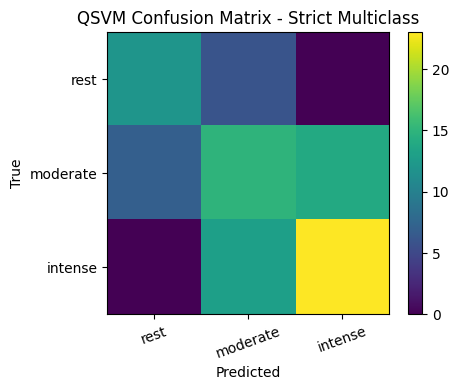

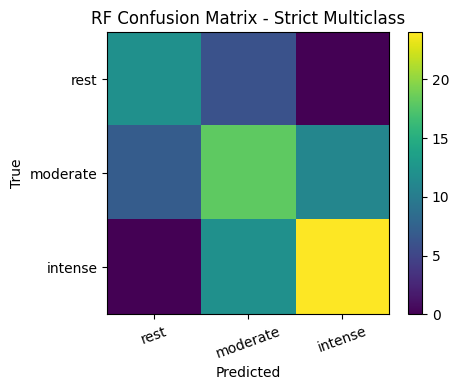

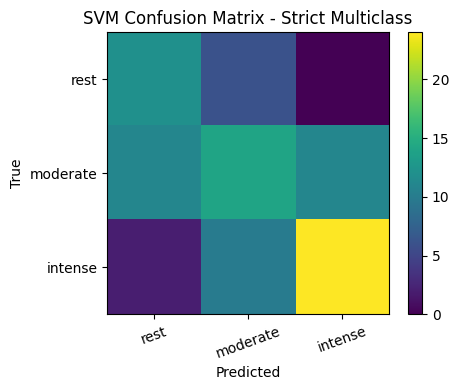

In [17]:
target_names = ["rest", "moderate", "intense"]

cm_qsvm = confusion_matrix(all_true_qsvm, all_preds_qsvm)
cm_rf = confusion_matrix(all_true_rf, all_preds_rf)
cm_svm = confusion_matrix(all_true_svm, all_preds_svm)

for cm, title, filename in [
    (cm_qsvm, "QSVM Confusion Matrix - Strict Multiclass", "chart_qsvm_strict_multiclass_confusion_matrix.png"),
    (cm_rf, "RF Confusion Matrix - Strict Multiclass", "chart_rf_strict_multiclass_confusion_matrix.png"),
    (cm_svm, "SVM Confusion Matrix - Strict Multiclass", "chart_svm_strict_multiclass_confusion_matrix.png"),
]:
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0,1,2], target_names, rotation=20)
    plt.yticks([0,1,2], target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300)
    plt.show()

## 18) Comparison table

In [18]:
qsvm_report = classification_report(
    all_true_qsvm, all_preds_qsvm, target_names=target_names, output_dict=True
)
rf_report = classification_report(
    all_true_rf, all_preds_rf, target_names=target_names, output_dict=True
)
svm_report = classification_report(
    all_true_svm, all_preds_svm, target_names=target_names, output_dict=True
)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "QSVM": [
        results_qsvm_df["accuracy"].mean(),
        qsvm_report["macro avg"]["precision"],
        qsvm_report["macro avg"]["recall"],
        qsvm_report["macro avg"]["f1-score"]
    ],
    "Random Forest": [
        results_rf_df["accuracy"].mean(),
        rf_report["macro avg"]["precision"],
        rf_report["macro avg"]["recall"],
        rf_report["macro avg"]["f1-score"]
    ],
    "SVM": [
        results_svm_df["accuracy"].mean(),
        svm_report["macro avg"]["precision"],
        svm_report["macro avg"]["recall"],
        svm_report["macro avg"]["f1-score"]
    ]
})

comparison_df

,Metric,QSVM,Random Forest,SVM
0,Accuracy,0.555556,0.600000,0.555556
1,Precision,0.564792,0.605764,0.544127
2,Recall,0.574074,0.611111,0.574074
3,F1-score,0.569119,0.608235,0.552813


## 19) Comparison chart

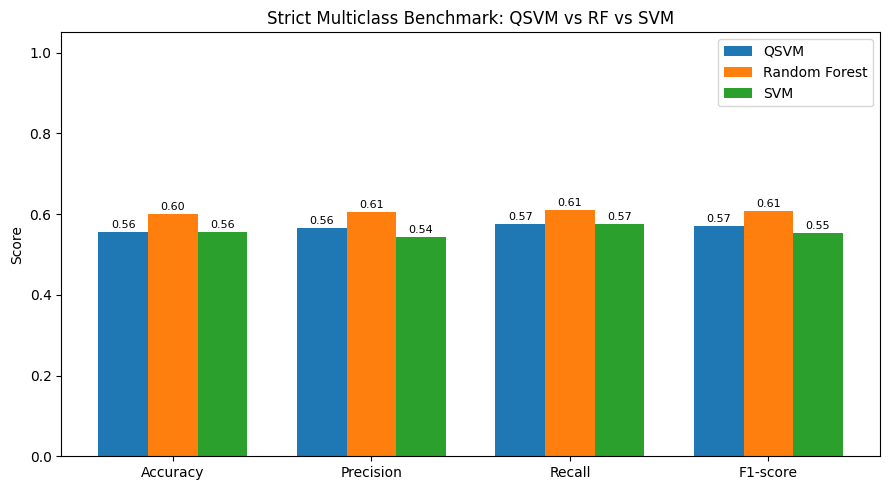

In [19]:
metrics = comparison_df["Metric"]
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, comparison_df["QSVM"], width, label="QSVM")
plt.bar(x, comparison_df["Random Forest"], width, label="Random Forest")
plt.bar(x + width, comparison_df["SVM"], width, label="SVM")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Strict Multiclass Benchmark: QSVM vs RF vs SVM")
plt.legend()

for i, v in enumerate(comparison_df["QSVM"]):
    plt.text(i - width, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

for i, v in enumerate(comparison_df["Random Forest"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

for i, v in enumerate(comparison_df["SVM"]):
    plt.text(i + width, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_qsvm_strict_multiclass_comparison.png", dpi=300)
plt.show()

## 20) File-by-file accuracy chart

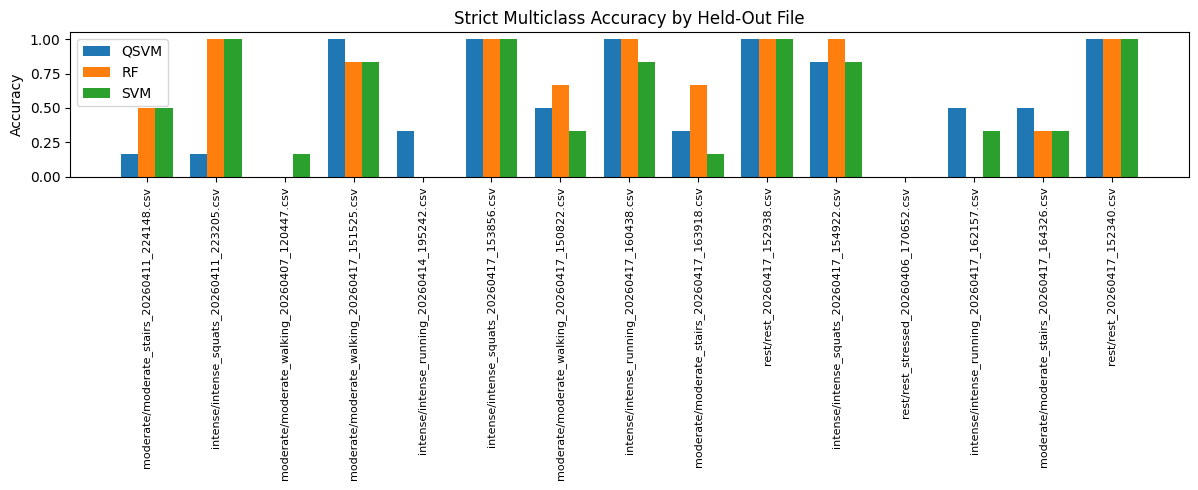

In [20]:
results_plot = pd.DataFrame({
    "test_file": results_qsvm_df["test_file"],
    "QSVM": results_qsvm_df["accuracy"].values,
    "RF": results_rf_df["accuracy"].values,
    "SVM": results_svm_df["accuracy"].values
})

x = np.arange(len(results_plot))
width = 0.25

plt.figure(figsize=(12,5))
plt.bar(x - width, results_plot["QSVM"], width, label="QSVM")
plt.bar(x, results_plot["RF"], width, label="RF")
plt.bar(x + width, results_plot["SVM"], width, label="SVM")

plt.xticks(x, results_plot["test_file"], rotation=90, fontsize=8)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Strict Multiclass Accuracy by Held-Out File")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_qsvm_strict_multiclass_by_file_accuracy.png", dpi=300)
plt.show()

## 21) Save results CSVs

In [21]:
results_qsvm_df.to_csv(OUTPUT_DIR / "qsvm_strict_multiclass_results_by_file.csv", index=False)
results_rf_df.to_csv(OUTPUT_DIR / "rf_strict_multiclass_results_by_file.csv", index=False)
results_svm_df.to_csv(OUTPUT_DIR / "svm_strict_multiclass_results_by_file.csv", index=False)

comparison_df.to_csv(OUTPUT_DIR / "qsvm_strict_multiclass_comparison_table.csv", index=False)

print("Saved strict multiclass comparison CSV files.")

Saved strict multiclass comparison CSV files.


## 22) Save confusion matrices as CSV

In [22]:
pd.DataFrame(
    cm_qsvm,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
).to_csv(OUTPUT_DIR / "qsvm_strict_multiclass_confusion_matrix.csv")

pd.DataFrame(
    cm_rf,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
).to_csv(OUTPUT_DIR / "rf_strict_multiclass_confusion_matrix.csv")

pd.DataFrame(
    cm_svm,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
).to_csv(OUTPUT_DIR / "svm_strict_multiclass_confusion_matrix.csv")

print("Saved strict multiclass confusion matrices.")

Saved strict multiclass confusion matrices.


## 23) Save summary text file

In [23]:
with open(LOGS_DIR / "qsvm_strict_multiclass_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("Strict Multiclass Benchmark: QSVM vs RF vs SVM\n")
    f.write("=" * 72)

    f.write("\n\nSelected features:\n")
    f.write(", ".join(selected_features))

    f.write("\n\nSampling strategy:\n")
    f.write(f"Maximum {MAX_WINDOWS_PER_FILE} windows per file")

    f.write("\n\nQSVM file-by-file results:\n")
    f.write(results_qsvm_df.to_string(index=False))
    f.write("\n\nMean QSVM leave-one-file-out accuracy:\n")
    f.write(str(results_qsvm_df["accuracy"].mean()))
    f.write("\n\nQSVM Classification Report:\n")
    f.write(classification_report(all_true_qsvm, all_preds_qsvm, target_names=target_names))

    f.write("\n\nRF file-by-file results:\n")
    f.write(results_rf_df.to_string(index=False))
    f.write("\n\nMean RF leave-one-file-out accuracy:\n")
    f.write(str(results_rf_df["accuracy"].mean()))
    f.write("\n\nRF Classification Report:\n")
    f.write(classification_report(all_true_rf, all_preds_rf, target_names=target_names))

    f.write("\n\nSVM file-by-file results:\n")
    f.write(results_svm_df.to_string(index=False))
    f.write("\n\nMean SVM leave-one-file-out accuracy:\n")
    f.write(str(results_svm_df["accuracy"].mean()))
    f.write("\n\nSVM Classification Report:\n")
    f.write(classification_report(all_true_svm, all_preds_svm, target_names=target_names))

    f.write("\n\nComparison Table:\n")
    f.write(comparison_df.to_string(index=False))

print("Saved strict multiclass quantum benchmark summary.")

Saved strict multiclass quantum benchmark summary.


NOTE: To keep strict multiclass QSVM evaluation computationally feasible, the experiment used a reduced four-feature representation and a capped number of six windows per file, while preserving leave-one-file-out validation.

# CONCLUSION
This notebook evaluates multiclass QSVM under the same strict leave-one-file-out validation protocol used for the classical models. Because quantum kernel methods are computationally expensive, the experiment was performed on a compact four-feature representation with limited windows per session. The results provide a tractable multiclass quantum benchmark that complements the stronger classical activity-recognition pipeline and the binary strict QSVM experiment.